In [61]:
# ============================================================================
# NOTEBOOK 01: EXPLORATORY DATA ANALYSIS & DATA CLEANING
# KDHS Early Childhood Development Study
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency
import seaborn as sns

# Add src to path
sys.path.insert(0, str(Path.cwd().parent.parent))
from src.data import (
    load_and_clean_data, get_data_paths, ECD_COLS, DOMAIN_ITEMS,
    sorted_bar, plot_top_counts
)

print("Imports successful")

Imports successful


In [62]:
# ============================================================================
# Load and Clean Data
# ============================================================================

df, paths = load_and_clean_data(save_interim=True)
print(f"\nFinal dataset shape: {df.shape}")


STEP 1: LOAD RAW KDHS DATA
✅ Loaded KDHS data from: /Users/collinsbiwott/Desktop/ecd_final_ml/data/raw/KEKR8CFL.SAV
RAW KDHS DATASET
Rows    : 19,530
Columns : 1,312

STEP 2: RENAME COLUMNS
✅ Renamed columns: 36 columns matched and renamed
AFTER COLUMN RENAME
Rows    : 19,530
Columns : 1,312

STEP 3: SELECT RELEVANT VARIABLES
✅ Selected relevant variables: 36 columns kept
AFTER SELECTING RELEVANT VARIABLES
Rows    : 19,530
Columns : 36

Selected columns:
['child_age_months', 'child_sex', 'mother_age', 'mother_education_level', 'mother_years_education', 'mother_currently_working', 'marital_status', 'religion', 'wealth_quintile', 'urban_rural', 'county', 'drinking_water_source', 'toilet_facility', 'has_electricity', 'cooking_fuel', 'household_members', 'phys_walk_uneven_surface', 'phys_jump_two_feet', 'phys_dress_self', 'phys_buttons', 'lang_words_10plus', 'lang_sentence_3plus', 'lang_sentence_5plus', 'lang_use_pronouns', 'lang_name_objects', 'lit_letters_5plus', 'lit_write_name', 'lit_

In [63]:
# ============================================================================
# Basic Data Info
# ============================================================================

print("\n" + "="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes.value_counts())

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0].head(20))


DATA TYPES
string     33
float64     3
bool        1
Name: count, dtype: int64

MISSING VALUES
                          Missing  Percent
phys_walk_uneven_surface     4023    52.77
phys_jump_two_feet           4023    52.77
phys_dress_self              4023    52.77
phys_buttons                 4023    52.77
lang_words_10plus            4023    52.77
lang_sentence_3plus          4023    52.77
lang_sentence_5plus          4025    52.79
lang_use_pronouns            4023    52.77
lang_name_objects            4023    52.77
lit_letters_5plus            4023    52.77
lit_write_name               4023    52.77
lit_numbers_1_5              4023    52.77
lit_count_3_objects          4023    52.77
lit_count_10_objects         4023    52.77
soc_independent_activity     4023    52.77
soc_name_familiar_people     4023    52.77
soc_help_others              4023    52.77
soc_get_along_children       4023    52.77
soc_often_sad                4023    52.77
soc_aggressive_behavior      4023    52.77


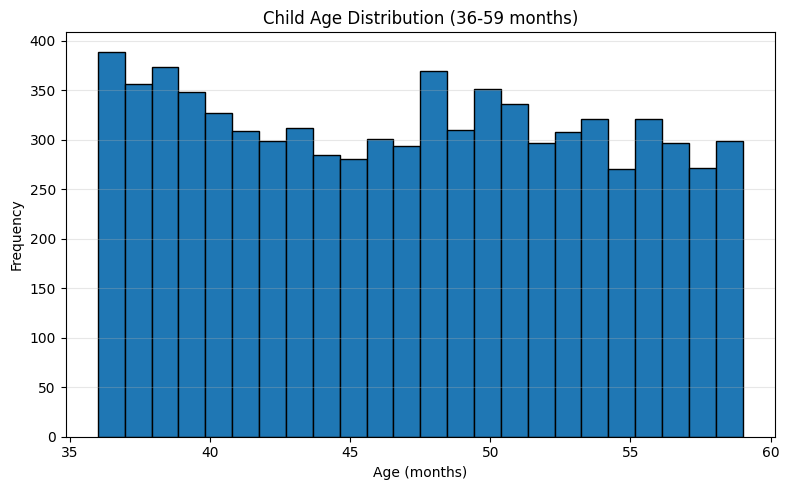

In [64]:
# ============================================================================
# Age Distribution
# ============================================================================

plt.figure(figsize=(8, 5))
df["child_age_months"].plot(kind="hist", bins=24, edgecolor='black')
plt.title("Child Age Distribution (36-59 months)")
plt.xlabel("Age (months)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(paths['figures'] / 'age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

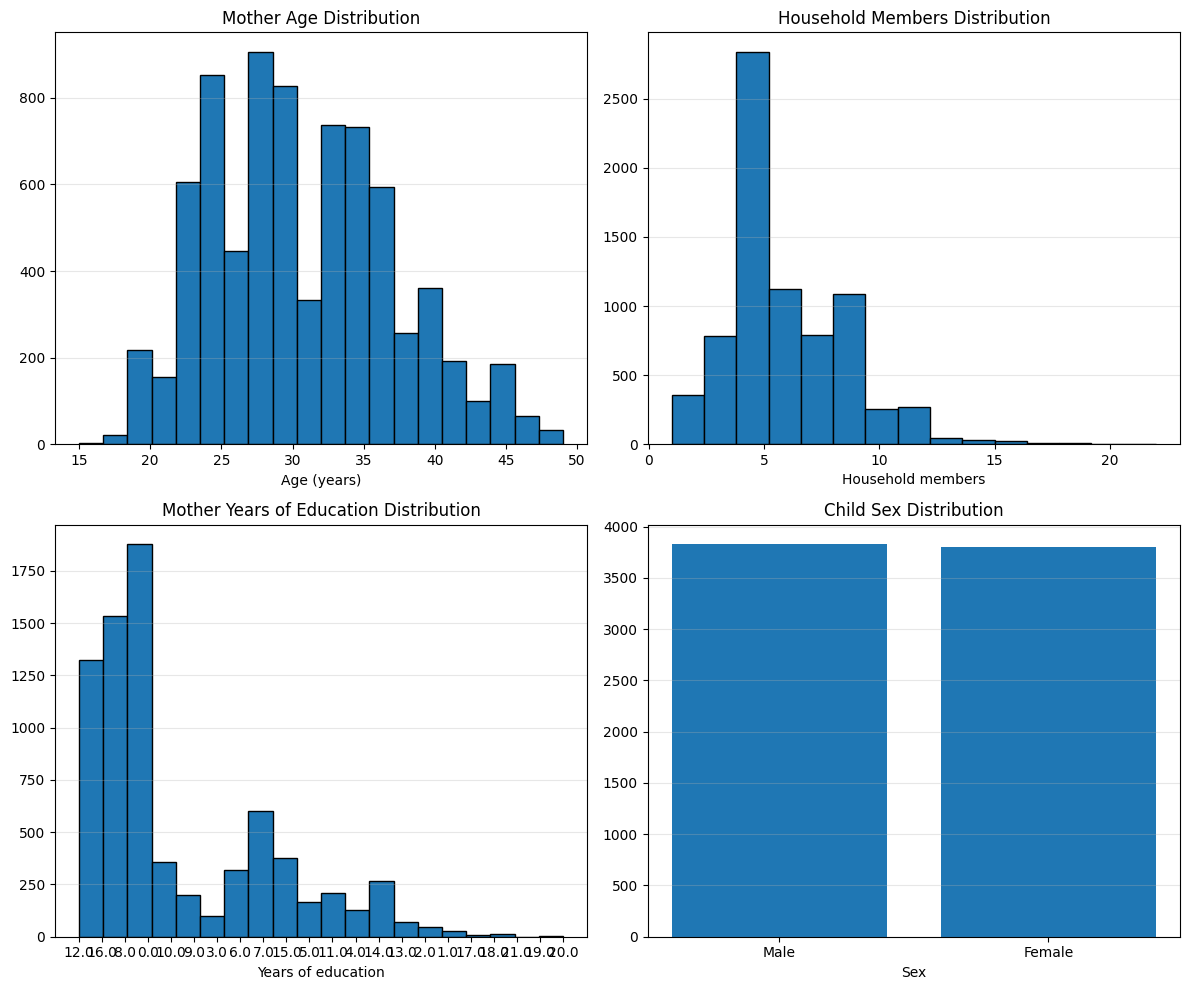

In [65]:
# ============================================================================
# Key Variable Distributions
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(df["mother_age"].dropna(), bins=20, edgecolor='black')
axes[0, 0].set_title("Mother Age Distribution")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].hist(df["household_members"].dropna(), bins=15, edgecolor='black')
axes[0, 1].set_title("Household Members Distribution")
axes[0, 1].set_xlabel("Household members")
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].hist(df["mother_years_education"].dropna(), bins=20, edgecolor='black')
axes[1, 0].set_title("Mother Years of Education Distribution")
axes[1, 0].set_xlabel("Years of education")
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(
    df["child_sex"].value_counts().index,
    df["child_sex"].value_counts().values
)
axes[1, 1].set_title("Child Sex Distribution")
axes[1, 1].set_xlabel("Sex")
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(paths['figures'] / 'key_variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


CORRELATION OF SELECTED PREDICTORS
Predictor dataset shape: (7624, 16)

Correlation matrix shape: (16, 16)


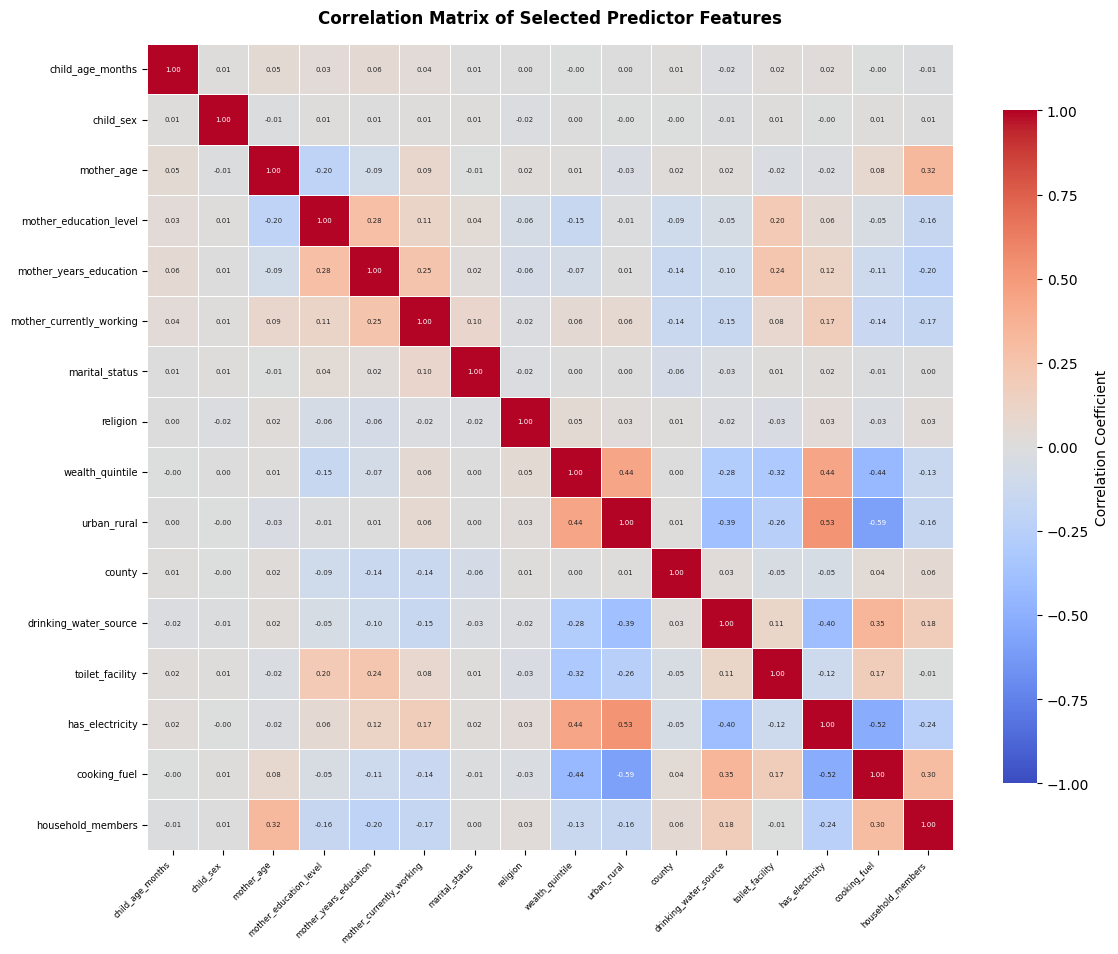


TOP 10 STRONGEST CORRELATIONS (Absolute Value)
urban_rural            cooking_fuel            -0.590437
                       has_electricity          0.526646
has_electricity        cooking_fuel            -0.519561
wealth_quintile        urban_rural              0.444562
                       has_electricity          0.438723
                       cooking_fuel            -0.436794
drinking_water_source  has_electricity         -0.398508
urban_rural            drinking_water_source   -0.385279
drinking_water_source  cooking_fuel             0.346649
mother_age             household_members        0.322051
dtype: float64

Predictor correlation analysis completed.
Heatmap saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/figures/predictor_correlation_heatmap_full.png
CSV saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/predictor_correlation_matrix.csv


In [66]:
# ============================================================================
# Correlation of Selected Predictors
# ============================================================================

print("\n" + "="*70)
print("CORRELATION OF SELECTED PREDICTORS")
print("="*70)

predictor_cols = [
    "child_age_months", "child_sex", "mother_age",
    "mother_education_level", "mother_years_education",
    "mother_currently_working", "marital_status", "religion",
    "wealth_quintile", "urban_rural", "county",
    "drinking_water_source", "toilet_facility",
    "has_electricity", "cooking_fuel", "household_members"
]

df_pred = df[predictor_cols].copy()
print("Predictor dataset shape:", df_pred.shape)

bool_cols = df_pred.select_dtypes(include="bool").columns
df_pred[bool_cols] = df_pred[bool_cols].astype(int)

cat_cols = df_pred.select_dtypes(include=["object", "string", "category"]).columns
for col in cat_cols:
    df_pred[col] = df_pred[col].astype("category").cat.codes

corr_matrix = df_pred.corr(method="spearman")
print("\nCorrelation matrix shape:", corr_matrix.shape)

plt.figure(figsize=(12, 10))
annot = np.round(corr_matrix, 2)

sns.heatmap(
    corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, annot=annot, fmt=".2f",
    annot_kws={"size": 5}, cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Correlation Matrix of Selected Predictor Features", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(pad=2.0)

plt.savefig(paths["figures"] / "predictor_correlation_heatmap_full.png", dpi=400, bbox_inches="tight")
plt.show()

corr_matrix.to_csv(paths["tables"] / "predictor_correlation_matrix.csv")

print("\n" + "="*70)
print("TOP 10 STRONGEST CORRELATIONS (Absolute Value)")
print("="*70)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
stacked = upper_tri.stack().sort_values(ascending=False, key=abs)
print(stacked.head(10))

print("\nPredictor correlation analysis completed.")
print(f"Heatmap saved to: {paths['figures'] / 'predictor_correlation_heatmap_full.png'}")
print(f"CSV saved to: {paths['tables'] / 'predictor_correlation_matrix.csv'}")


DOMAIN-LEVEL CORRELATION ANALYSIS

Column dtypes after conversion:
phys_walk_uneven_surface    float64
phys_jump_two_feet          float64
phys_dress_self             float64
phys_buttons                float64
lang_words_10plus           float64
lang_sentence_3plus         float64
lang_sentence_5plus         float64
lang_use_pronouns           float64
lang_name_objects           float64
lit_letters_5plus           float64
lit_write_name              float64
lit_numbers_1_5             float64
lit_count_3_objects         float64
lit_count_10_objects        float64
soc_independent_activity    float64
soc_name_familiar_people    float64
soc_help_others             float64
soc_get_along_children      float64
soc_often_sad               float64
soc_aggressive_behavior     float64
dtype: object

Domain dataset shape: (7624, 4)

Preview of domain scores:
   physical_score  language_score  literacy_score  social_score
1             1.5             2.0             1.2      2.833333
2         

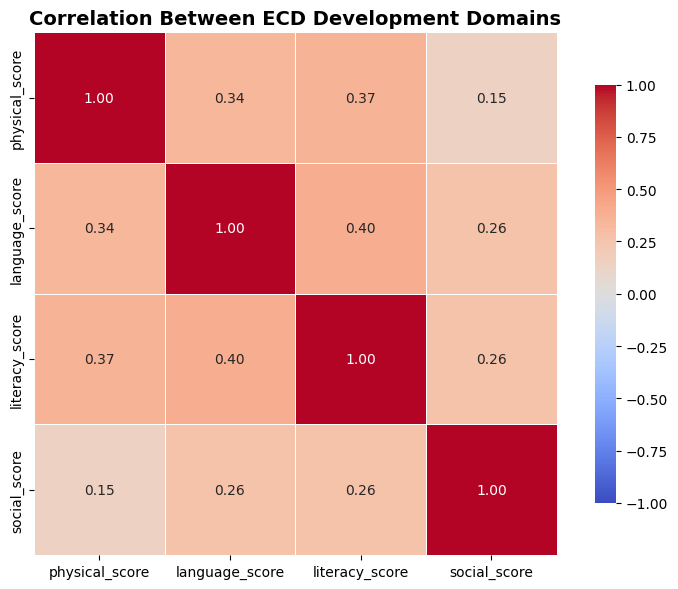


Domain correlation analysis completed.
Saved:
 - /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/ecd_domain_correlations.csv
 - /Users/collinsbiwott/Desktop/ecd_final_ml/reports/figures/ecd_domain_correlation_heatmap.png


In [67]:
# ============================================================================
# Domain-Level Correlation Analysis
# ============================================================================

print("\n" + "="*70)
print("DOMAIN-LEVEL CORRELATION ANALYSIS")
print("="*70)

physical_cols = ["phys_walk_uneven_surface", "phys_jump_two_feet", 
                 "phys_dress_self", "phys_buttons"]
language_cols = ["lang_words_10plus", "lang_sentence_3plus", 
                 "lang_sentence_5plus", "lang_use_pronouns", "lang_name_objects"]
literacy_cols = ["lit_letters_5plus", "lit_write_name", "lit_numbers_1_5", 
                 "lit_count_3_objects", "lit_count_10_objects"]
social_cols = ["soc_independent_activity", "soc_name_familiar_people", 
               "soc_help_others", "soc_get_along_children", 
               "soc_often_sad", "soc_aggressive_behavior"]

all_domain_cols = physical_cols + language_cols + literacy_cols + social_cols

df_domains_raw = df[all_domain_cols].copy()

bool_cols = df_domains_raw.select_dtypes(include=["bool"]).columns
df_domains_raw[bool_cols] = df_domains_raw[bool_cols].astype(int)

string_cols = df_domains_raw.select_dtypes(include=["object", "string", "category"]).columns
for col in string_cols:
    df_domains_raw[col] = df_domains_raw[col].astype("category").cat.codes
    df_domains_raw[col] = df_domains_raw[col].replace(-1, pd.NA)

for col in all_domain_cols:
    df_domains_raw[col] = pd.to_numeric(df_domains_raw[col], errors="coerce")

print("\nColumn dtypes after conversion:")
print(df_domains_raw.dtypes)

df_domains = pd.DataFrame(index=df.index)
df_domains["physical_score"] = df_domains_raw[physical_cols].mean(axis=1)
df_domains["language_score"] = df_domains_raw[language_cols].mean(axis=1)
df_domains["literacy_score"] = df_domains_raw[literacy_cols].mean(axis=1)
df_domains["social_score"] = df_domains_raw[social_cols].mean(axis=1)

print("\nDomain dataset shape:", df_domains.shape)
print("\nPreview of domain scores:")
print(df_domains.head())

domain_corr = df_domains.corr(method="spearman")

print("\nCorrelation Matrix:")
print(domain_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    domain_corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Between ECD Development Domains", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

domain_corr.to_csv(paths["tables"] / "ecd_domain_correlations.csv")

plt.figure(figsize=(8, 6))
sns.heatmap(
    domain_corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.5, square=True
)
plt.title("Correlation Between ECD Development Domains", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(paths["figures"] / "ecd_domain_correlation_heatmap.png", dpi=400, bbox_inches="tight")
plt.close()

print("\nDomain correlation analysis completed.")
print("Saved:")
print(" -", paths["tables"] / "ecd_domain_correlations.csv")
print(" -", paths["figures"] / "ecd_domain_correlation_heatmap.png")

In [68]:
# ============================================================================
# Recode ECD Items to Numeric (0/1)
# ============================================================================

from src.data import recode_ecd_items, ECD_COLS

df = recode_ecd_items(df)

print("\nECD items recoded to numeric")
print(f"ECD columns dtypes:\n{df[ECD_COLS].dtypes}")
print(f"\nSample ECD values:\n{df[ECD_COLS].head()}")

✅ Recoded ECD items to numeric for 20 columns

ECD items recoded to numeric
ECD columns dtypes:
phys_walk_uneven_surface    float64
phys_jump_two_feet          float64
phys_dress_self             float64
phys_buttons                float64
lang_words_10plus           float64
lang_sentence_3plus         float64
lang_sentence_5plus         float64
lang_use_pronouns           float64
lang_name_objects           float64
lit_letters_5plus           float64
lit_write_name              float64
lit_numbers_1_5             float64
lit_count_3_objects         float64
lit_count_10_objects        float64
soc_independent_activity    float64
soc_name_familiar_people    float64
soc_help_others             float64
soc_get_along_children      float64
soc_often_sad               float64
soc_aggressive_behavior     float64
dtype: object

Sample ECD values:
   phys_walk_uneven_surface  phys_jump_two_feet  phys_dress_self  \
1                       1.0                 1.0              0.0   
2             

In [69]:
# ============================================================================
# Calculate Milestone Counts and Domain Scores (CRITICAL FOR NOTEBOOK 02)
# ============================================================================

print("\n" + "="*60)
print("CALCULATING MILESTONE COUNTS AND DOMAIN SCORES")
print("="*60)

# Create domain scores in MAIN df
df['physical_score'] = df[physical_cols].mean(axis=1, skipna=True)
df['language_score'] = df[language_cols].mean(axis=1, skipna=True)
df['literacy_score'] = df[literacy_cols].mean(axis=1, skipna=True)
df['socio_emotional_score'] = df[social_cols].mean(axis=1, skipna=True)

# Calculate milestone counts
df['physical_count'] = df[physical_cols].sum(axis=1, skipna=True)
df['language_count'] = df[language_cols].sum(axis=1, skipna=True)
df['literacy_count'] = df[literacy_cols].sum(axis=1, skipna=True)
df['socio_emotional_count'] = df[social_cols].sum(axis=1, skipna=True)

# Total milestone count (CRITICAL for Notebook 02)
all_ecd_items = physical_cols + language_cols + literacy_cols + social_cols
df['ecd_milestone_count'] = df[all_ecd_items].sum(axis=1, skipna=True)

print("\nMilestone count summary:")
print(df['ecd_milestone_count'].describe())

print("\nDomain score summary:")
for col in ['physical_score', 'language_score', 'literacy_score', 'socio_emotional_score']:
    print(f"  {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")

print("\nSample milestone counts:")
print(df[['ecd_milestone_count', 'physical_count', 'language_count', 
          'literacy_count', 'socio_emotional_count']].head(10))


CALCULATING MILESTONE COUNTS AND DOMAIN SCORES

Milestone count summary:
count    7624.000000
mean        5.883919
std         6.748886
min         0.000000
25%         0.000000
50%         0.000000
75%        13.000000
max        18.000000
Name: ecd_milestone_count, dtype: float64

Domain score summary:
  physical_score: mean=0.778, std=0.260
  language_score: mean=0.871, std=0.244
  literacy_score: mean=0.378, std=0.347
  socio_emotional_score: mean=0.779, std=0.268

Sample milestone counts:
    ecd_milestone_count  physical_count  language_count  literacy_count  \
1                  12.0             2.0             5.0             1.0   
2                  18.0             4.0             5.0             5.0   
3                   0.0             0.0             0.0             0.0   
7                  10.0             2.0             4.0             1.0   
9                   0.0             0.0             0.0             0.0   
12                  0.0             0.0           

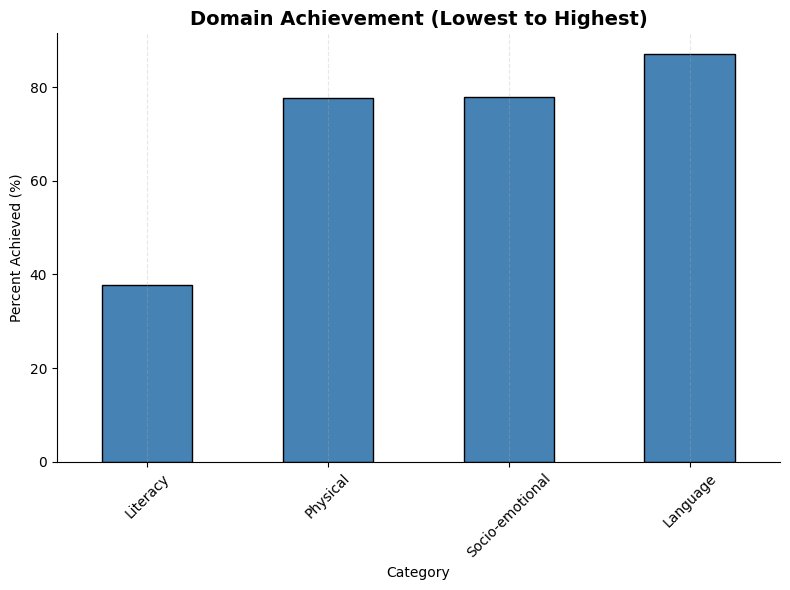

<Figure size 640x480 with 0 Axes>

In [70]:
# ============================================================================
# Domain Achievement
# ============================================================================

domain_means = pd.Series({
    "Physical": df[physical_cols].mean().mean(),
    "Language": df[language_cols].mean().mean(),
    "Literacy": df[literacy_cols].mean().mean(),
    "Socio-emotional": df[social_cols].mean().mean()
}).sort_values()

sorted_bar(
    domain_means, horizontal=False, percent=True,
    title="Domain Achievement (Lowest to Highest)",
    xlabel="Percent Achieved (%)"
)
plt.savefig(paths['figures'] / 'domain_achievement.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
# ============================================================================
# Completeness by Groups
# ============================================================================

print("\nComplete ECD by Urban/Rural (%):")
print((df.groupby("urban_rural", observed=False)["complete_ecd_strict"].mean() * 100).round(2))

print("\nComplete ECD by Wealth Quintile (%):")
print((df.groupby("wealth_quintile", observed=False)["complete_ecd_strict"].mean() * 100).round(2))


Complete ECD by Urban/Rural (%):
urban_rural
Rural    49.16
Urban    43.48
Name: complete_ecd_strict, dtype: float64

Complete ECD by Wealth Quintile (%):
wealth_quintile
Middle     45.12
Poorer     48.01
Poorest    50.14
Richer     43.56
Richest    46.56
Name: complete_ecd_strict, dtype: float64


In [72]:
# ============================================================================
# Urban vs Rural: Domain Comparison
# ============================================================================

domain_scores = {
    'Physical': 'physical_score',
    'Language': 'language_score',
    'Literacy': 'literacy_score',
    'Socio-emotional': 'socio_emotional_score'
}

df_urban = df[df['urban_rural'].notna()].copy()
print(f"\nUrban/Rural analysis: {len(df_urban)} children")
print(f"   Distribution:\n{df_urban['urban_rural'].value_counts()}")


Urban/Rural analysis: 7624 children
   Distribution:
urban_rural
Rural    5000
Urban    2624
Name: count, dtype: Int64



VISUALIZATION 1: Domain Score Distributions (Urban vs Rural)


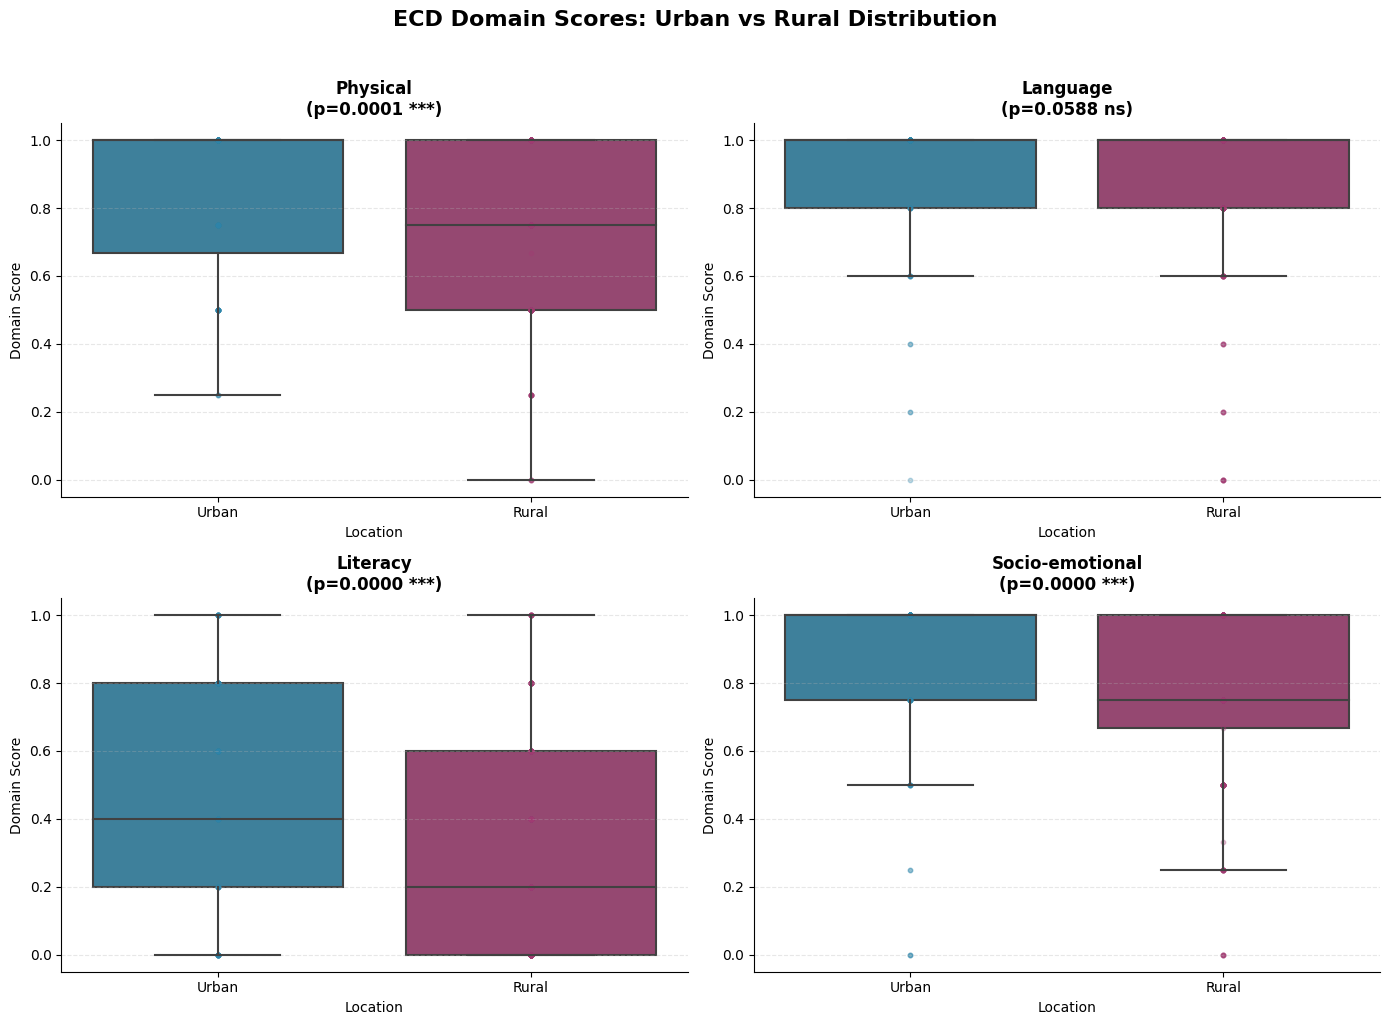

In [73]:
# VISUALIZATION 1: Side-by-Side Box Plots
print("\nVISUALIZATION 1: Domain Score Distributions (Urban vs Rural)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ECD Domain Scores: Urban vs Rural Distribution', fontsize=16, fontweight='bold', y=1.02)

colors = {'Urban': '#2E86AB', 'Rural': '#A23B72'}

for ax, (domain_name, score_col) in zip(axes.flat, domain_scores.items()):
    if score_col not in df_urban.columns:
        continue

    sns.boxplot(
        data=df_urban, x='urban_rural', y=score_col,
        ax=ax, palette=colors, linewidth=1.5, showfliers=False
    )

    if len(df_urban) > 1000:
        sample_df = df_urban.sample(500, random_state=42)
        for i, location in enumerate(['Urban', 'Rural']):
            if location in sample_df['urban_rural'].values:
                data = sample_df[sample_df['urban_rural'] == location][score_col].dropna()
                ax.scatter([i] * len(data), data, color=colors[location], alpha=0.3, s=10, zorder=1)

    urban_vals = df_urban[df_urban['urban_rural'] == 'Urban'][score_col].dropna()
    rural_vals = df_urban[df_urban['urban_rural'] == 'Rural'][score_col].dropna()

    if len(urban_vals) > 10 and len(rural_vals) > 10:
        t_stat, p_val = stats.ttest_ind(urban_vals, rural_vals, equal_var=False)
        sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.set_title(f'{domain_name}\n(p={p_val:.4f} {sig_marker})', fontsize=12, fontweight='bold')
    else:
        ax.set_title(domain_name, fontsize=12, fontweight='bold')

    ax.set_xlabel('Location', fontsize=10)
    ax.set_ylabel('Domain Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(paths['figures'] / 'urban_rural_domains.png', dpi=300, bbox_inches='tight')
plt.show()



VISUALIZATION 2: Mean Domain Scores with 95% CI


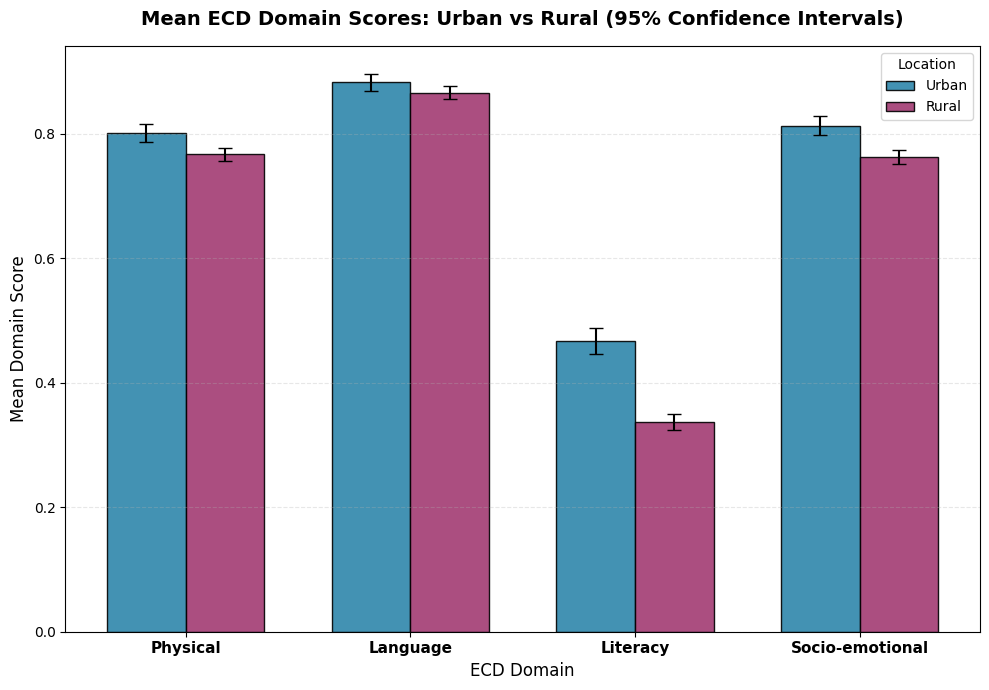


Saved Urban/Rural domain summary to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/urban_rural_domain_summary.csv


In [74]:
# ============================================================================
# VISUALIZATION 2: Mean Scores with 95% Confidence Intervals
# ============================================================================

print("\nVISUALIZATION 2: Mean Domain Scores with 95% CI")
print("="*70)

summary_data = []
for domain_name, score_col in domain_scores.items():
    if score_col not in df_urban.columns:
        continue
    for location in ['Urban', 'Rural']:
        vals = df_urban[df_urban['urban_rural'] == location][score_col].dropna()
        if len(vals) > 0:
            mean = vals.mean()
            sem = vals.std() / np.sqrt(len(vals))
            ci_low = mean - stats.t.ppf(0.975, len(vals) - 1) * sem
            ci_high = mean + stats.t.ppf(0.975, len(vals) - 1) * sem
            summary_data.append({
                'Domain': domain_name,
                'Location': location,
                'Mean': mean,
                'CI_Low': ci_low,
                'CI_High': ci_high,
                'N': len(vals)
            })

summary_df = pd.DataFrame(summary_data)

plt.figure(figsize=(10, 7))
x_pos = np.arange(len(domain_scores))
width = 0.35

for i, location in enumerate(['Urban', 'Rural']):
    loc_data = summary_df[summary_df['Location'] == location]
    means = [
        loc_data[loc_data['Domain'] == d]['Mean'].values[0]
        if len(loc_data[loc_data['Domain'] == d]) > 0 else np.nan
        for d in domain_scores.keys()
    ]
    ci_low = [
        loc_data[loc_data['Domain'] == d]['CI_Low'].values[0]
        if len(loc_data[loc_data['Domain'] == d]) > 0 else np.nan
        for d in domain_scores.keys()
    ]
    ci_high = [
        loc_data[loc_data['Domain'] == d]['CI_High'].values[0]
        if len(loc_data[loc_data['Domain'] == d]) > 0 else np.nan
        for d in domain_scores.keys()
    ]

    yerr = [[m - l for m, l in zip(means, ci_low)], [h - m for h, m in zip(ci_high, means)]]

    plt.bar(
        x_pos + i * width, means, width, label=location,
        color=colors[location], edgecolor='black',
        yerr=yerr, capsize=5, alpha=0.9
    )

plt.xticks(x_pos + width / 2, list(domain_scores.keys()), fontsize=11, fontweight='bold')
plt.xlabel('ECD Domain', fontsize=12)
plt.ylabel('Mean Domain Score', fontsize=12)
plt.title('Mean ECD Domain Scores: Urban vs Rural (95% Confidence Intervals)', fontsize=14, fontweight='bold', pad=15)
plt.legend(title='Location', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

summary_df.to_csv(paths['tables'] / 'urban_rural_domain_summary.csv', index=False)
print(f"\nSaved Urban/Rural domain summary to: {paths['tables'] / 'urban_rural_domain_summary.csv'}")


VISUALIZATION 3: Effect Size (Urban vs Rural)
Physical             | d =  0.133 | Negligible | Urban > Rural
Language             | d =  0.067 | Negligible | Urban > Rural
Literacy             | d =  0.381 | Small    | Urban > Rural
Socio-emotional      | d =  0.189 | Negligible | Urban > Rural


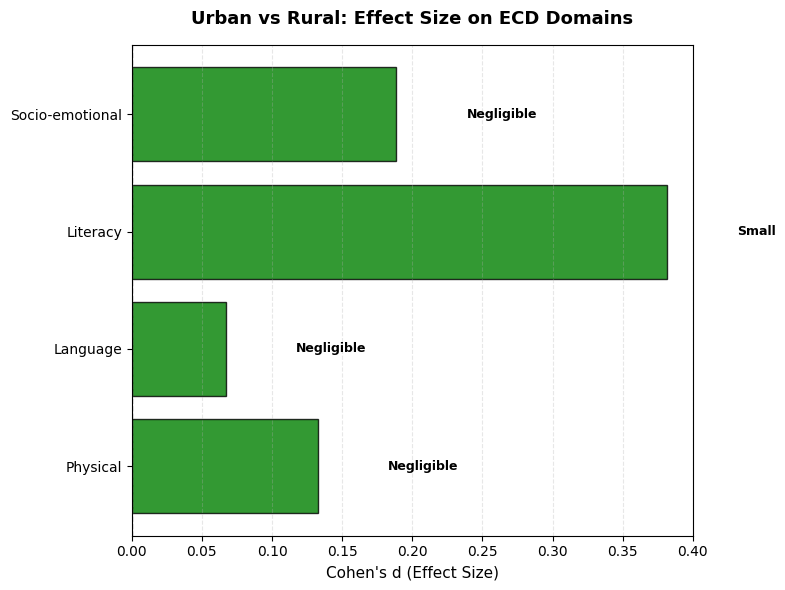


Saved effect sizes to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/urban_rural_effect_sizes.csv


In [75]:
# ============================================================================
# VISUALIZATION 3: Effect Size (Cohen's d)
# ============================================================================

print("\nVISUALIZATION 3: Effect Size (Urban vs Rural)")
print("="*70)

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0
    return (np.mean(group1) - np.mean(group2)) / pooled_std

effect_sizes = []
for domain_name, score_col in domain_scores.items():
    if score_col not in df_urban.columns:
        continue

    urban_vals = df_urban[df_urban['urban_rural'] == 'Urban'][score_col].dropna()
    rural_vals = df_urban[df_urban['urban_rural'] == 'Rural'][score_col].dropna()

    if len(urban_vals) > 10 and len(rural_vals) > 10:
        d = cohens_d(urban_vals, rural_vals)

        if abs(d) < 0.2:
            interpretation = 'Negligible'
        elif abs(d) < 0.5:
            interpretation = 'Small'
        elif abs(d) < 0.8:
            interpretation = 'Medium'
        else:
            interpretation = 'Large'

        effect_sizes.append({
            'Domain': domain_name,
            "Cohen's d": d,
            'Interpretation': interpretation,
            'Direction': 'Urban > Rural' if d > 0 else 'Rural > Urban'
        })

        print(f"{domain_name:20} | d = {d:6.3f} | {interpretation:8} | {('Urban > Rural' if d > 0 else 'Rural > Urban')}")

if effect_sizes:
    effect_df = pd.DataFrame(effect_sizes)

    plt.figure(figsize=(8, 6))
    colors_eff = ['green' if d > 0 else 'red' for d in effect_df["Cohen's d"]]
    plt.barh(
        effect_df['Domain'], effect_df["Cohen's d"],
        color=colors_eff, edgecolor='black', alpha=0.8
    )
    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel("Cohen's d (Effect Size)", fontsize=11)
    plt.title('Urban vs Rural: Effect Size on ECD Domains', fontsize=13, fontweight='bold', pad=15)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    for i, (_, row) in enumerate(effect_df.iterrows()):
        plt.text(
            row["Cohen's d"] + (0.05 if row["Cohen's d"] > 0 else -0.15),
            i, f"{row['Interpretation']}",
            va='center', fontsize=9, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    effect_df.to_csv(paths['tables'] / 'urban_rural_effect_sizes.csv', index=False)
    print(f"\nSaved effect sizes to: {paths['tables'] / 'urban_rural_effect_sizes.csv'}")


VISUALIZATION 4: Achievement Rates (Score >= 0.8) by Location


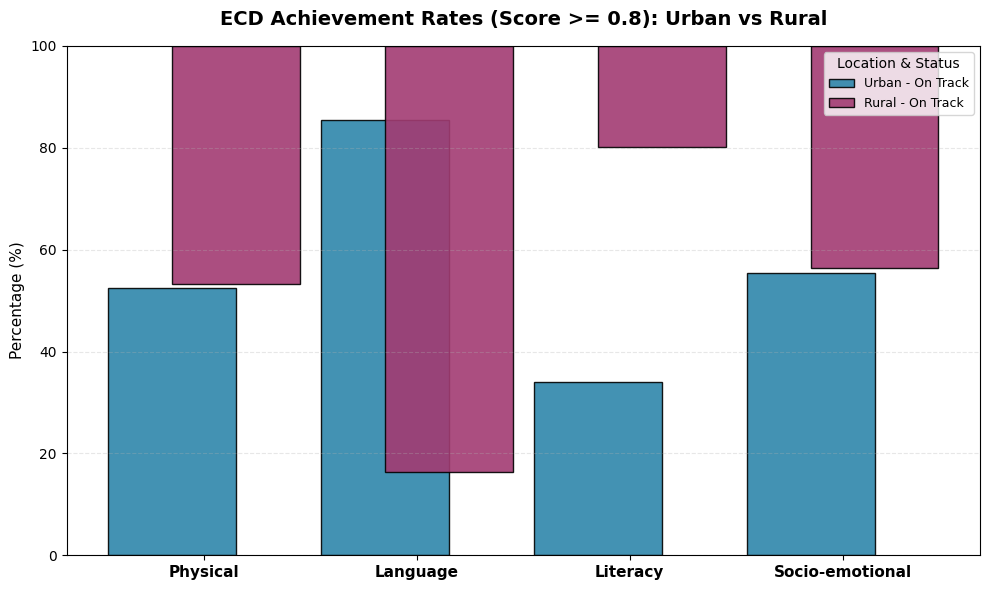


Saved achievement rates to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/urban_rural_achievement_rates.csv


In [76]:
# ============================================================================
# VISUALIZATION 4: Achievement Rates
# ============================================================================

print("\nVISUALIZATION 4: Achievement Rates (Score >= 0.8) by Location")
print("="*70)

achievement_data = []
for domain_name, score_col in domain_scores.items():
    if score_col not in df_urban.columns:
        continue
    for location in ['Urban', 'Rural']:
        vals = df_urban[df_urban['urban_rural'] == location][score_col].dropna()
        if len(vals) > 0:
            on_track = (vals >= 0.8).sum()
            delayed = len(vals) - on_track
            achievement_data.append({
                'Domain': domain_name,
                'Location': location,
                'On_Track': on_track,
                'Delayed': delayed,
                'On_Track_Pct': on_track / len(vals) * 100,
                'N': len(vals)
            })

ach_df = pd.DataFrame(achievement_data)

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(domain_scores))
width = 0.6

for i, location in enumerate(['Urban', 'Rural']):
    loc_data = ach_df[ach_df['Location'] == location]
    on_track = [
        loc_data[loc_data['Domain'] == d]['On_Track_Pct'].values[0]
        if len(loc_data[loc_data['Domain'] == d]) > 0 else 0
        for d in domain_scores.keys()
    ]

    bottom = np.zeros(len(domain_scores)) if i == 0 else [100 - ot for ot in on_track]

    ax.bar(
        x_pos + (i - 0.5) * width / 2, on_track, width,
        label=f'{location} - On Track', color=colors[location],
        edgecolor='black', alpha=0.9, bottom=bottom if i == 1 else None
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(list(domain_scores.keys()), fontsize=11, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('ECD Achievement Rates (Score >= 0.8): Urban vs Rural', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Location & Status', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

ach_df.to_csv(paths['tables'] / 'urban_rural_achievement_rates.csv', index=False)
print(f"\nSaved achievement rates to: {paths['tables'] / 'urban_rural_achievement_rates.csv'}")

In [77]:
# ============================================================================
# Summary Table for Dissertation
# ============================================================================

print("\n" + "="*70)
print("URBAN vs RURAL: DISSERTATION SUMMARY TABLE")
print("="*70)

dissertation_summary = []
for domain_name, score_col in domain_scores.items():
    if score_col not in df_urban.columns:
        continue

    urban_vals = df_urban[df_urban['urban_rural'] == 'Urban'][score_col].dropna()
    rural_vals = df_urban[df_urban['urban_rural'] == 'Rural'][score_col].dropna()

    if len(urban_vals) > 10 and len(rural_vals) > 10:
        t_stat, p_val = stats.ttest_ind(urban_vals, rural_vals, equal_var=False)
        d = cohens_d(urban_vals, rural_vals)

        dissertation_summary.append({
            'Domain': domain_name,
            'Urban_Mean (SD)': f"{urban_vals.mean():.3f} ({urban_vals.std():.3f})",
            'Rural_Mean (SD)': f"{rural_vals.mean():.3f} ({rural_vals.std():.3f})",
            'N_Urban': len(urban_vals),
            'N_Rural': len(rural_vals),
            't_statistic': f"{t_stat:.3f}",
            'p_value': f"{p_val:.4f}",
            "Cohen's_d": f"{d:.3f}",
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

diss_df = pd.DataFrame(dissertation_summary)
print(diss_df.to_string(index=False))

diss_df.to_csv(paths['tables'] / 'urban_rural_dissertation_summary.csv', index=False)
print(f"\nSaved dissertation summary table to: {paths['tables'] / 'urban_rural_dissertation_summary.csv'}")

print("\n" + "="*70)
print("URBAN vs RURAL ANALYSIS COMPLETE")
print("="*70)


URBAN vs RURAL: DISSERTATION SUMMARY TABLE
         Domain Urban_Mean (SD) Rural_Mean (SD)  N_Urban  N_Rural t_statistic p_value Cohen's_d Significant
       Physical   0.801 (0.248)   0.767 (0.265)     1141     2458       3.802  0.0001     0.133         Yes
       Language   0.882 (0.239)   0.866 (0.246)     1142     2458       1.891  0.0588     0.067          No
       Literacy   0.467 (0.361)   0.337 (0.332)     1142     2458      10.326  0.0000     0.381         Yes
Socio-emotional   0.813 (0.260)   0.763 (0.271)     1142     2458       5.349  0.0000     0.189         Yes

Saved dissertation summary table to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/urban_rural_dissertation_summary.csv

URBAN vs RURAL ANALYSIS COMPLETE


In [78]:
# ============================================================================
# Verify Required Columns Before Saving
# ============================================================================

print("\n" + "="*60)
print("VERIFYING REQUIRED COLUMNS")
print("="*60)

required_cols = ['ecd_milestone_count', 'physical_score', 'language_score', 
                 'literacy_score', 'socio_emotional_score', 'complete_ecd_strict']

for col in required_cols:
    if col in df.columns:
        print(f"  {col}: {df[col].notna().sum()} non-null values")
    else:
        print(f"  WARNING: {col} NOT FOUND")


VERIFYING REQUIRED COLUMNS
  ecd_milestone_count: 7624 non-null values
  physical_score: 3599 non-null values
  language_score: 3600 non-null values
  literacy_score: 3600 non-null values
  socio_emotional_score: 3600 non-null values
  complete_ecd_strict: 7624 non-null values


In [79]:
# ============================================================================
# Save Clean Dataset
# ============================================================================

df.to_parquet(paths['interim'] / 'kr_clean.parquet', index=False)
print(f"\nClean dataset saved to: {paths['interim'] / 'kr_clean.parquet'}")
print(f"Final shape: {df.shape}")


Clean dataset saved to: /Users/collinsbiwott/Desktop/ecd_final_ml/data/interim/kr_clean.parquet
Final shape: (7624, 46)


In [80]:
# ============================================================================
# Summary
# ============================================================================

print("\n" + "="*60)
print("NOTEBOOK 01 SUMMARY")
print("="*60)
print(f"""
Data cleaning complete
Sample: {len(df):,} children aged 36-59 months

Key outputs:
  - kr_clean.parquet: Clean dataset with domain scores and milestone counts
  - predictor_correlation_heatmap_full.png: Feature correlations
  - ecd_domain_correlation_heatmap.png: Domain correlations
  - urban_rural_domains.png: Urban vs Rural domain comparisons
  - urban_rural_domain_summary.csv: Statistical summary table

Next: Notebook 02 - Create targets & compare on-track vs delayed
""")

print("NOTEBOOK 01 COMPLETE")


NOTEBOOK 01 SUMMARY

Data cleaning complete
Sample: 7,624 children aged 36-59 months

Key outputs:
  - kr_clean.parquet: Clean dataset with domain scores and milestone counts
  - predictor_correlation_heatmap_full.png: Feature correlations
  - ecd_domain_correlation_heatmap.png: Domain correlations
  - urban_rural_domains.png: Urban vs Rural domain comparisons
  - urban_rural_domain_summary.csv: Statistical summary table

Next: Notebook 02 - Create targets & compare on-track vs delayed

NOTEBOOK 01 COMPLETE
